# Model Deployment Course – Dependency Check Notebook

This notebook verifies that all dependencies required for the **Model Deployment** course can be imported and run correctly.

It covers all course sessions:
- **Session 02**: Iris Classification + MLflow Experiment Tracking + Model Registry
- **Session 04**: ML Pipeline Pattern (Iris) with MLflow
- **Session 05**: Customer Churn – Manual Preprocessing vs sklearn Pipeline
- **Session 06-07**: FastAPI & Streamlit Deployment
- **Session 12**: OOP Design Pattern + GridSearchCV + Pickle

> Run all cells from top to bottom. If all cells execute without errors, the environment is (almost) ready.


## Section 0: Dependency Smoke Test

Import all packages used across all sessions.

In [1]:
# ── Core libraries ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
print(f"numpy  {np.__version__}")
print(f"pandas {pd.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"seaborn {sns.__version__}")


numpy  2.4.2
pandas 2.3.3
matplotlib 3.10.8
seaborn 0.13.2


In [2]:
# ── Scikit-learn ──────────────────────────────────────────────────────────
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
print(f"scikit-learn {sklearn.__version__}")


scikit-learn 1.8.0


In [3]:
# ── Optuna ────────────────────────────────────────────────────────────────
import optuna
print(f"optuna {optuna.__version__}")


optuna 4.7.0


In [4]:
# ── MLflow ────────────────────────────────────────────────────────────────
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
print(f"mlflow {mlflow.__version__}")


mlflow 3.10.0


In [5]:
# ── Model serialization ───────────────────────────────────────────────────
import joblib
import pickle
print("joblib and pickle imported OK")


joblib and pickle imported OK


In [6]:
# ── API & UI ──────────────────────────────────────────────────────────────
import fastapi
import pydantic
import uvicorn
import streamlit
import requests
print(f"fastapi    {fastapi.__version__}")
print(f"pydantic   {pydantic.__version__}")
print(f"uvicorn    {uvicorn.__version__}")
print(f"streamlit  {streamlit.__version__}")
print(f"requests   {requests.__version__}")
print("\nAll dependencies imported successfully!")


fastapi    0.129.2
pydantic   2.12.5
uvicorn    0.41.0
streamlit  1.54.0
requests   2.32.5

All dependencies imported successfully!


---
## Section 1: Session 02 – Iris Classification with MLflow

Topics covered:
- Logistic Regression, SVM, Random Forest
- Optuna hyperparameter optimization
- MLflow experiment tracking (log params, metrics, artifacts, models)
- MLflow Model Registry with aliases (champion / challenger)


### 1.1 Load Data & Prepare

In [7]:
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

iris = load_iris()
X, y = iris.data, iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[t] for t in y]

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())
df.head()


Dataset shape: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")


Train: (120, 4)  |  Test: (30, 4)


### 1.2 Baseline Models

In [9]:
# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))


=== Logistic Regression ===
Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [10]:
# SVM
svm = SVC(random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)
print("=== SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))


=== SVM ===
Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [11]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))


=== Random Forest ===
Accuracy: 0.9000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### 1.3 Confusion Matrices

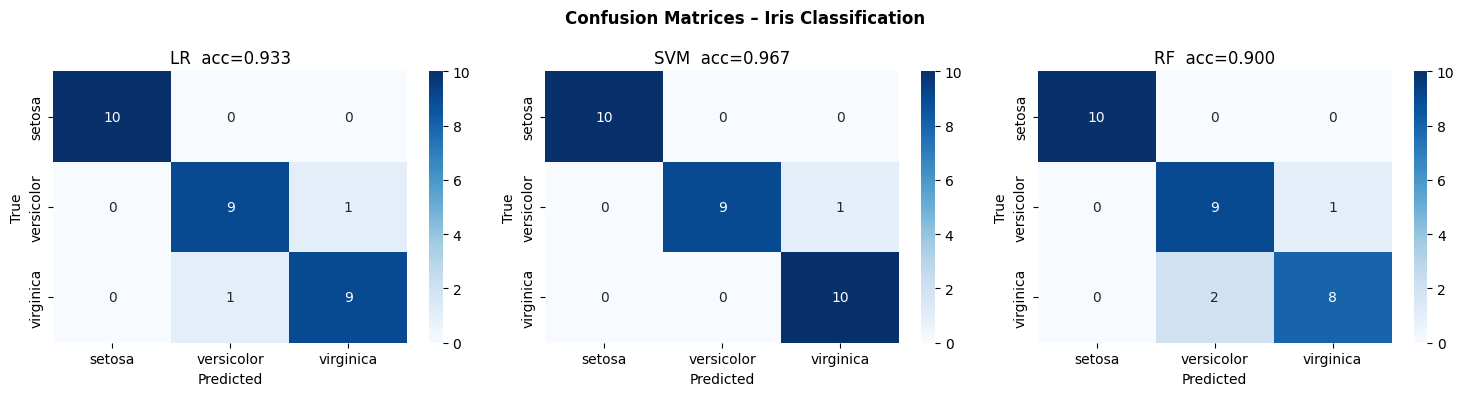

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [("LR", y_pred_lr), ("SVM", y_pred_svm), ("RF", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    ax.set_title(f"{name}  acc={accuracy_score(y_test, y_pred):.3f}")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.suptitle("Confusion Matrices – Iris Classification", fontweight='bold')
plt.tight_layout()
plt.show()


### 1.4 Optuna Hyperparameter Optimization

In [13]:
def objective(trial):
    params = dict(
        max_depth         = trial.suggest_int('max_depth', 2, 10),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        criterion         = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
    )
    model = RandomForestClassifier(**params, random_state=42)
    return cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy').mean()

print("Running Optuna (50 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"Best CV accuracy: {study.best_value:.4f}")
print(f"Best params:      {study.best_trial.params}")


Running Optuna (50 trials)...
Best CV accuracy: 0.9583
Best params:      {'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}


In [14]:
best_params = study.best_trial.params
rf_opt = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_opt.fit(X_train_sc, y_train)
y_pred_rf_opt = rf_opt.predict(X_test_sc)
print("=== Random Forest (Optimized) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(classification_report(y_test, y_pred_rf_opt, target_names=iris.target_names))


=== Random Forest (Optimized) ===
Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### 1.5 MLflow Experiment Tracking

In [15]:
import os
# Use SQLite backend (filesystem backend is deprecated as of Feb 2026)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("iris-classification-demo")
print(f"MLflow URI: {mlflow.get_tracking_uri()}")
print("Run `mlflow ui` to view the dashboard at http://localhost:5000")

2026/02/22 19:52:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/22 19:52:50 INFO mlflow.store.db.utils: Updating database tables
2026/02/22 19:52:53 INFO mlflow.tracking.fluent: Experiment with name 'iris-classification-demo' does not exist. Creating a new experiment.


MLflow URI: sqlite:///mlflow.db
Run `mlflow ui` to view the dashboard at http://localhost:5000


In [16]:
# Log Logistic Regression run
with mlflow.start_run(run_name="logistic_regression_baseline") as run:
    mlflow.set_tag("model_type", "logistic_regression")
    mlflow.log_params({"C": 1.0, "solver": "lbfgs", "random_state": 42})
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_lr))
    sig = infer_signature(X_train_sc, lr.predict(X_train_sc))
    mlflow.sklearn.log_model(lr, name="model", signature=sig)
    print(f"LR run logged | Run ID: {run.info.run_id}")


2026/02/22 19:52:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:53:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LR run logged | Run ID: 6ec181d5ef3b40bc9f79b683bcf59994


In [17]:
# Log SVM run
with mlflow.start_run(run_name="svm_baseline") as run:
    mlflow.set_tag("model_type", "svm")
    mlflow.log_params({"kernel": "rbf", "C": 1.0, "random_state": 42})
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_svm))
    sig = infer_signature(X_train_sc, svm.predict(X_train_sc))
    mlflow.sklearn.log_model(svm, name="model", signature=sig)
    print(f"SVM run logged | Run ID: {run.info.run_id}")


2026/02/22 19:53:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:53:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


SVM run logged | Run ID: 34d6cef8c9244a49b59cd00035342157


In [18]:
# Log Random Forest Baseline run
with mlflow.start_run(run_name="random_forest_baseline") as run:
    mlflow.set_tag("model_type", "random_forest")
    mlflow.log_params({"n_estimators": 100, "max_depth": "None", "random_state": 42})
    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred_rf))
    sig = infer_signature(X_train_sc, rf.predict(X_train_sc))
    mlflow.sklearn.log_model(rf, name="model", signature=sig)
    print(f"RF baseline run logged | Run ID: {run.info.run_id}")


2026/02/22 19:53:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:53:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


RF baseline run logged | Run ID: 4d22facd6c634ae6971e8a181922c864


### 1.6 MLflow with Nested Runs (Optuna trials)

In [19]:
def objective_mlflow(trial):
    with mlflow.start_run(run_name=f"rf_trial_{trial.number}", nested=True):
        p = dict(
            max_depth         = trial.suggest_int('max_depth', 2, 10),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 10),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
            max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            criterion         = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        )
        mlflow.log_params(p)
        model  = RandomForestClassifier(**p, random_state=42)
        scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
        mlflow.log_metric("cv_accuracy_mean", scores.mean())
        return scores.mean()

print("Running Optuna + MLflow nested runs (20 trials for speed)...")
with mlflow.start_run(run_name="rf_optuna_optimization") as parent:
    study2 = optuna.create_study(direction='maximize')
    study2.optimize(objective_mlflow, n_trials=20)
    mlflow.log_metric("best_cv_accuracy", study2.best_value)
    mlflow.log_param("n_trials", 20)
    print(f"Parent run ID: {parent.info.run_id}")
    print(f"Best CV: {study2.best_value:.4f}")


Running Optuna + MLflow nested runs (20 trials for speed)...
Parent run ID: 5c8c3a06ca3e46c4b770d7a327da7b40
Best CV: 0.9583


### 1.7 MLflow Model Registry

In [20]:
MODEL_NAME = "iris-rf-optimized-notebook"

with mlflow.start_run(run_name="rf_final_optimized") as final_run:
    mlflow.set_tag("status", "production_candidate")
    rf_final = RandomForestClassifier(**study.best_trial.params, random_state=42)
    rf_final.fit(X_train_sc, y_train)
    y_pred_final = rf_final.predict(X_test_sc)

    mlflow.log_params(study.best_trial.params)
    mlflow.log_metric("train_accuracy", accuracy_score(y_train, rf_final.predict(X_train_sc)))
    mlflow.log_metric("test_accuracy",  accuracy_score(y_test, y_pred_final))

    sig = infer_signature(X_train_sc, rf_final.predict(X_train_sc))
    mlflow.sklearn.log_model(rf_final, name="model", signature=sig,
                              input_example=X_train_sc[:3],
                              registered_model_name=MODEL_NAME)
    final_run_id = final_run.info.run_id

print(f"Model registered as: {MODEL_NAME}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred_final):.4f}")


2026/02/22 19:54:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:54:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model registered as: iris-rf-optimized-notebook
Test accuracy: 0.9333


Successfully registered model 'iris-rf-optimized-notebook'.
Created version '1' of model 'iris-rf-optimized-notebook'.


In [21]:
client = MlflowClient()

# Update description
client.update_registered_model(MODEL_NAME,
    description="RF classifier for Iris, optimized with Optuna.")

# Set challenger alias
versions = client.search_model_versions(f"name='{MODEL_NAME}'")
latest   = max(versions, key=lambda v: int(v.version))
client.set_registered_model_alias(MODEL_NAME, "challenger", latest.version)
print(f"Set alias 'challenger' → version {latest.version}")

# Load model by alias
loaded_model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@challenger")
loaded_acc   = accuracy_score(y_test, loaded_model.predict(X_test_sc))
print(f"Loaded challenger model accuracy: {loaded_acc:.4f}")

# Promote to champion
client.set_registered_model_alias(MODEL_NAME, "champion", latest.version)
client.delete_registered_model_alias(MODEL_NAME, "challenger")
print(f"Version {latest.version} promoted to 'champion'!")


Set alias 'challenger' → version 1
Loaded challenger model accuracy: 0.9333
Version 1 promoted to 'champion'!


In [22]:
# Load production (champion) model
prod_uri   = f"models:/{MODEL_NAME}@champion"
prod_model = mlflow.sklearn.load_model(prod_uri)
preds      = prod_model.predict(X_test_sc[:5])
print("Sample predictions:", preds)
print("Species:          ", [iris.target_names[p] for p in preds])


Sample predictions: [0 2 1 1 0]
Species:           [np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa')]


---
## Section 2: Session 04 – ML Pipeline Pattern (Iris)

Topics covered:
- Separating ML code into modules: `data_ingestion`, `pre_processing`, `train`, `evaluation`, `pipeline`
- MLflow experiment tracking within each step
- Streamlit deployment concept


### 2.1 Data Ingestion Function

In [23]:
import os

def ingest_data_iris(output_dir="ingested_iris"):
    os.makedirs(output_dir, exist_ok=True)
    iris_raw = load_iris()
    df = pd.DataFrame(iris_raw.data, columns=['sepal_length','sepal_width',
                                               'petal_length','petal_width'])
    df['species'] = [iris_raw.target_names[t] for t in iris_raw.target]
    out_path = f"{output_dir}/IRIS.csv"
    df.to_csv(out_path, index=False)
    print(f"Data ingested → {out_path}  | shape: {df.shape}")
    return out_path

iris_csv_path = ingest_data_iris()


Data ingested → ingested_iris/IRIS.csv  | shape: (150, 5)


### 2.2 Preprocessing Function

In [24]:
def preprocess_iris(csv_path, artifacts_dir="artifacts_iris"):
    os.makedirs(artifacts_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    X  = df.drop("species", axis=1)
    y  = df["species"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    sc = StandardScaler()
    X_train_sc = pd.DataFrame(sc.fit_transform(X_train)).reset_index(drop=True)
    X_test_sc  = pd.DataFrame(sc.transform(X_test)).reset_index(drop=True)

    joblib.dump(sc, f"{artifacts_dir}/preprocessor.pkl")

    train_scaled = pd.concat([X_train_sc, y_train.reset_index(drop=True)], axis=1)
    test_scaled  = pd.concat([X_test_sc,  y_test.reset_index(drop=True)],  axis=1)

    print(f"Scaler saved | Train: {train_scaled.shape}  Test: {test_scaled.shape}")
    return train_scaled, test_scaled

train_scaled_iris, test_scaled_iris = preprocess_iris(iris_csv_path)


Scaler saved | Train: (120, 5)  Test: (30, 5)


### 2.3 Training Function (with MLflow)

In [25]:
def train_iris(train_scaled, experiment_name="Iris-Pipeline"):
    mlflow.set_experiment(experiment_name)
    X_tr = train_scaled.drop("species", axis=1)
    y_tr = train_scaled["species"]

    with mlflow.start_run(run_name="iris_rf_train") as run:
        model = RandomForestClassifier(criterion='gini', max_depth=4, random_state=42)
        model.fit(X_tr, y_tr)
        mlflow.log_params({"criterion": "gini", "max_depth": 4})
        mlflow.sklearn.log_model(model, name="model")
        print(f"Model trained | Run ID: {run.info.run_id}")
        return run.info.run_id

iris_run_id = train_iris(train_scaled_iris)


2026/02/22 19:54:18 INFO mlflow.tracking.fluent: Experiment with name 'Iris-Pipeline' does not exist. Creating a new experiment.
2026/02/22 19:54:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:54:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model trained | Run ID: dd4953db85f4464ab2d9fe5a08060f39


### 2.4 Evaluation Function

In [26]:
def evaluate_iris(test_scaled, run_id):
    X_te = test_scaled.drop("species", axis=1)
    y_te = test_scaled["species"]
    model = mlflow.sklearn.load_model(f"runs:/{run_id}/model")

    preds = model.predict(X_te)

    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average="macro")
    rec  = recall_score(y_te, preds, average="macro")

    with mlflow.start_run(run_id=run_id):
        mlflow.log_metrics({"accuracy": acc, "precision": prec, "recall": rec})

    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}")
    return acc, prec, rec

acc_iris, prec_iris, rec_iris = evaluate_iris(test_scaled_iris, iris_run_id)


Accuracy=0.967  Precision=0.970  Recall=0.967


### 2.5 Complete Pipeline Orchestrator

In [27]:
ACCURACY_THRESHOLD = 0.9

def run_iris_pipeline():
    print("Step 1: Data Ingestion")
    csv = ingest_data_iris()

    print("\nStep 2: Preprocessing")
    train_sc, test_sc = preprocess_iris(csv)

    print("\nStep 3: Training")
    run_id = train_iris(train_sc)

    print("\nStep 4: Evaluation")
    accuracy, _, _ = evaluate_iris(test_sc, run_id)

    print("\n" + "="*45)
    if accuracy >= ACCURACY_THRESHOLD:
        print(f"Model APPROVED for deployment  (acc={accuracy:.3f})")
    else:
        print(f"Model REJECTED  (acc={accuracy:.3f} < {ACCURACY_THRESHOLD})")

run_iris_pipeline()


Step 1: Data Ingestion
Data ingested → ingested_iris/IRIS.csv  | shape: (150, 5)

Step 2: Preprocessing
Scaler saved | Train: (120, 5)  Test: (30, 5)

Step 3: Training


2026/02/22 19:54:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:54:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model trained | Run ID: 8bbdfbd958ab4aa2a774e4b4999892c5

Step 4: Evaluation


Accuracy=0.967  Precision=0.970  Recall=0.967

Model APPROVED for deployment  (acc=0.967)


### 2.6 Streamlit App (Code Reference)

```python
# app_streamlit.py  –  run with: streamlit run app_streamlit.py
import streamlit as st
import joblib, numpy as np

scaler = joblib.load("artifacts/preprocessor.pkl")
model  = joblib.load("artifacts/model.pkl")

def main():
    st.title("Iris Prediction")
    sepal_length = st.number_input("Sepal Length (cm)", 0.0, 10.0, 5.1)
    sepal_width  = st.number_input("Sepal Width (cm)",  0.0, 10.0, 3.5)
    petal_length = st.slider("Petal Length (cm)", 0.0, 10.0, 1.4)
    petal_width  = st.slider("Petal Width (cm)",  0.0, 10.0, 0.2)

    if st.button("Predict"):
        X = scaler.transform([[sepal_length, sepal_width, petal_length, petal_width]])
        pred = model.predict(X)[0]
        st.success(f"Predicted Species: {pred}")

if __name__ == "__main__":
    main()
```


---
## Section 3: Session 05 – Customer Churn Prediction

Two preprocessing approaches are demonstrated:
1. **No-Pipeline**: Manual imputation + encoding steps, artifacts saved separately
2. **sklearn Pipeline**: All preprocessing + classifier bundled in one Pipeline object


### 3.1 Generate Synthetic Churn Dataset

In [28]:
def generate_churn_data(n=2000, seed=42):
    rng = np.random.default_rng(seed)
    data = {
        "CustomerID":        range(1, n+1),
        "Age":               rng.integers(18, 70, n),
        "Gender":            rng.choice(["Male","Female",None], n, p=[0.55,0.44,0.01]),
        "Tenure":            [None if rng.random()<0.02 else int(x)
                              for x in rng.integers(1,61,n)],
        "Usage Frequency":   rng.integers(1, 30, n),
        "Support Calls":     [None if rng.random()<0.02 else int(x)
                              for x in rng.integers(0,11,n)],
        "Payment Delay":     rng.integers(0, 30, n),
        "Subscription Type": rng.choice(["Basic","Standard","Premium"], n),
        "Contract Length":   rng.choice(["Monthly","Quarterly","Annual"], n),
        "Total Spend":       [None if rng.random()<0.01 else int(x)
                              for x in rng.integers(100, 1001, n)],
        "Last Interaction":  rng.integers(1, 30, n),
        "Churn":             rng.choice([0, 1], n, p=[0.45, 0.55]),
    }
    return pd.DataFrame(data)

df_churn = generate_churn_data(n=2000)
print("Churn dataset shape:", df_churn.shape)
print("Churn distribution:")
print(df_churn['Churn'].value_counts())
df_churn.head(3)


Churn dataset shape: (2000, 12)
Churn distribution:
Churn
1    1098
0     902
Name: count, dtype: int64


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Male,38.0,15,4.0,1,Basic,Annual,311.0,21,1
1,2,58,Male,50.0,14,8.0,21,Premium,Quarterly,447.0,20,0
2,3,52,Male,39.0,3,0.0,6,Standard,Quarterly,125.0,27,0


### 3.2 Approach A – No-Pipeline (Manual Preprocessing)

In [29]:
# ── Split ──────────────────────────────────────────────────────────────────
X_churn  = df_churn.drop(['Churn','CustomerID'], axis=1)
y_churn  = df_churn['Churn']
x_tr, x_te, y_tr, y_te = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

# ── Missing value imputation ────────────────────────────────────────────────
impute_stats = {
    "tenure_mean":        x_tr['Tenure'].mean(),
    "support_calls_mean": x_tr['Support Calls'].mean(),
    "total_spend_mean":   x_tr['Total Spend'].mean(),
    "gender_mode":        x_tr['Gender'].mode()[0],
}
for df_ in [x_tr, x_te]:
    df_['Tenure']        = df_['Tenure'].fillna(impute_stats['tenure_mean'])
    df_['Support Calls'] = df_['Support Calls'].fillna(impute_stats['support_calls_mean'])
    df_['Total Spend']   = df_['Total Spend'].fillna(impute_stats['total_spend_mean'])
    df_['Gender']        = df_['Gender'].fillna(impute_stats['gender_mode'])

print("Missing values after imputation:")
print(x_tr.isnull().sum().sum(), "remaining in x_tr")


Missing values after imputation:
0 remaining in x_tr


In [30]:
# ── Encoding ───────────────────────────────────────────────────────────────
x_tr = x_tr.replace({"Gender": {"Male": 1, "Female": 0}})
x_te = x_te.replace({"Gender": {"Male": 1, "Female": 0}})

subs_enc = OrdinalEncoder(categories=[['Basic','Standard','Premium']],
                           handle_unknown='use_encoded_value', unknown_value=-1)
cont_enc = OrdinalEncoder(categories=[['Monthly','Quarterly','Annual']],
                           handle_unknown='use_encoded_value', unknown_value=-1)

for enc, col, new_col in [(subs_enc,'Subscription Type','Sub Ordinal'),
                           (cont_enc,'Contract Length','Cont Ordinal')]:
    tr_e = pd.DataFrame(enc.fit_transform(x_tr[[col]]), columns=[new_col])
    te_e = pd.DataFrame(enc.transform(x_te[[col]]),     columns=[new_col])
    x_tr = pd.concat([x_tr.reset_index(drop=True), tr_e], axis=1)
    x_te = pd.concat([x_te.reset_index(drop=True), te_e], axis=1)

x_tr_enc = x_tr.drop(['Subscription Type','Contract Length'], axis=1)
x_te_enc = x_te.drop(['Subscription Type','Contract Length'], axis=1)
print("Encoded features:", x_tr_enc.columns.tolist())


Encoded features: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Sub Ordinal', 'Cont Ordinal']


In [31]:
# ── Train + MLflow ─────────────────────────────────────────────────────────
mlflow.set_experiment("Churn-NoPipeline")

with mlflow.start_run(run_name="churn_nopipeline") as run:
    rf_churn_np = RandomForestClassifier(criterion='gini', max_depth=4, random_state=42)
    rf_churn_np.fit(x_tr_enc, y_tr)
    mlflow.log_params({"criterion": "gini", "max_depth": 4})
    mlflow.sklearn.log_model(rf_churn_np, name="model")
    np_run_id = run.info.run_id

# Evaluate
model_np = mlflow.sklearn.load_model(f"runs:/{np_run_id}/model")
preds_np  = model_np.predict(x_te_enc)
acc_np    = accuracy_score(y_te, preds_np)
prec_np   = precision_score(y_te, preds_np, average="macro")
rec_np    = recall_score(y_te, preds_np, average="macro")
with mlflow.start_run(run_id=np_run_id):
    mlflow.log_metrics({"accuracy": acc_np, "precision": prec_np, "recall": rec_np})

print("=== No-Pipeline Results ===")
print(classification_report(y_te, preds_np, target_names=['Stay','Churn']))


2026/02/22 19:54:38 INFO mlflow.tracking.fluent: Experiment with name 'Churn-NoPipeline' does not exist. Creating a new experiment.
2026/02/22 19:54:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:54:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


=== No-Pipeline Results ===
              precision    recall  f1-score   support

        Stay       0.00      0.00      0.00       180
       Churn       0.54      0.97      0.70       220

    accuracy                           0.54       400
   macro avg       0.27      0.49      0.35       400
weighted avg       0.30      0.54      0.38       400



### 3.3 Approach B – sklearn Pipeline (Preprocessing + Classifier)

In [32]:
# ── Rename columns for clean Pipeline usage ────────────────────────────────
df_churn2 = df_churn.rename(columns={
    "Usage Frequency":   "UsageFrequency",
    "Support Calls":     "SupportCalls",
    "Payment Delay":     "PaymentDelay",
    "Subscription Type": "SubscriptionType",
    "Contract Length":   "ContractLength",
    "Total Spend":       "TotalSpend",
    "Last Interaction":  "LastInteraction",
})

X2 = df_churn2.drop(['Churn','CustomerID'], axis=1)
y2 = df_churn2['Churn']
x_tr2, x_te2, y_tr2, y_te2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

num_feat = x_tr2.select_dtypes(include=['int64','float64']).columns.tolist()
cat_feat = x_tr2.select_dtypes(include=['object','category']).columns.tolist()
print("Numeric features: ", num_feat)
print("Categorical features:", cat_feat)


Numeric features:  ['Age', 'Tenure', 'UsageFrequency', 'SupportCalls', 'PaymentDelay', 'TotalSpend', 'LastInteraction']
Categorical features: ['Gender', 'SubscriptionType', 'ContractLength']


In [33]:
# ── Build Pipeline ─────────────────────────────────────────────────────────
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='mean'))])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['Male','Female'],
                    ['Basic','Standard','Premium'],
                    ['Monthly','Quarterly','Annual']], handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_feat),
    ('cat', cat_pipe, ['Gender','SubscriptionType','ContractLength']),
], remainder='drop')

churn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier',    RandomForestClassifier(criterion='gini', max_depth=4, random_state=42)),
])

print(churn_pipeline)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['Age', 'Tenure',
                                                   'UsageFrequency',
                                                   'SupportCalls',
                                                   'PaymentDelay', 'TotalSpend',
                                                   'LastInteraction']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                 

In [34]:
# ── Train Pipeline + MLflow ────────────────────────────────────────────────
mlflow.set_experiment("Customer-Churn-Pipeline")

with mlflow.start_run(run_name="churn_sklearn_pipeline") as run:
    mlflow.log_params({"criterion": "gini", "max_depth": 4})
    churn_pipeline.fit(x_tr2, y_tr2)
    mlflow.sklearn.log_model(churn_pipeline, name="model")
    pipe_run_id = run.info.run_id

# Evaluate
model_pipe  = mlflow.sklearn.load_model(f"runs:/{pipe_run_id}/model")
preds_pipe  = model_pipe.predict(x_te2)
acc_pipe    = accuracy_score(y_te2, preds_pipe)
prec_pipe   = precision_score(y_te2, preds_pipe, average="macro")
rec_pipe    = recall_score(y_te2, preds_pipe, average="macro")
with mlflow.start_run(run_id=pipe_run_id):
    mlflow.log_metrics({"accuracy": acc_pipe, "precision": prec_pipe, "recall": rec_pipe})

print("=== Pipeline Results ===")
print(classification_report(y_te2, preds_pipe, target_names=['Stay','Churn']))


2026/02/22 19:54:45 INFO mlflow.tracking.fluent: Experiment with name 'Customer-Churn-Pipeline' does not exist. Creating a new experiment.
2026/02/22 19:54:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/22 19:54:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


=== Pipeline Results ===
              precision    recall  f1-score   support

        Stay       0.20      0.01      0.02       180
       Churn       0.54      0.96      0.70       220

    accuracy                           0.54       400
   macro avg       0.37      0.49      0.36       400
weighted avg       0.39      0.54      0.39       400



### 3.4 Comparison: No-Pipeline vs Pipeline


            Approach  Accuracy  Precision   Recall
No-Pipeline (Manual)     0.535   0.271574 0.486364
    sklearn Pipeline     0.535   0.371795 0.487374


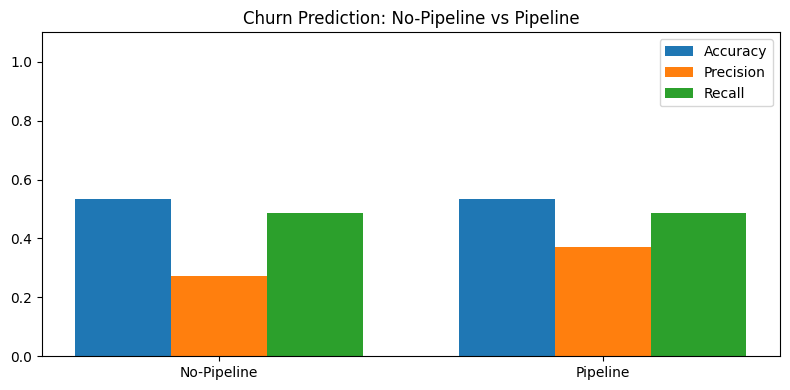

In [35]:
comparison = pd.DataFrame({
    "Approach":  ["No-Pipeline (Manual)", "sklearn Pipeline"],
    "Accuracy":  [acc_np, acc_pipe],
    "Precision": [prec_np, prec_pipe],
    "Recall":    [rec_np, rec_pipe],
})
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
bars1 = ax.bar(x - 0.25, comparison["Accuracy"],  0.25, label="Accuracy")
bars2 = ax.bar(x,         comparison["Precision"], 0.25, label="Precision")
bars3 = ax.bar(x + 0.25,  comparison["Recall"],    0.25, label="Recall")
ax.set_xticks(x)
ax.set_xticklabels(["No-Pipeline", "Pipeline"])
ax.set_ylim(0, 1.1)
ax.set_title("Churn Prediction: No-Pipeline vs Pipeline")
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 4: Session 06-07 – FastAPI & Streamlit Deployment

Topics covered:
- Creating a FastAPI REST API endpoint for model inference
- Pydantic input schema validation
- Streamlit frontend that calls the FastAPI backend
- Architecture: Streamlit → HTTP POST → FastAPI → Model → Response

> **Note**: FastAPI servers cannot be started inside a notebook.
> This section tests imports and demonstrates the code patterns.


### 4.1 Import Test

In [36]:
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn, requests

print("FastAPI:", fastapi.__version__)
print("Pydantic:", pydantic.__version__)
print("uvicorn:", uvicorn.__version__)
print("All API/UI libraries imported successfully!")


FastAPI: 0.129.2
Pydantic: 2.12.5
uvicorn: 0.41.0
All API/UI libraries imported successfully!


### 4.2 FastAPI App – Iris (Code Pattern)

In [37]:
# ── FastAPI Iris App (for reference – run with: uvicorn iris_fastapi:app --reload) ──
FASTAPI_IRIS_CODE = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app   = FastAPI(title="Iris Prediction API")
model = joblib.load("RF_class.pkl")

class IrisFeatures(BaseModel):
    sepal_length: float
    sepal_width:  float
    petal_length: float
    petal_width:  float

@app.get("/")
def root():
    return {"message": "Welcome to the Iris ML Model API"}

@app.post("/predict")
def predict(iris: IrisFeatures):
    data     = iris.dict()
    features = [[data["sepal_length"], data["sepal_width"],
                 data["petal_length"], data["petal_width"]]]
    prediction = model.predict(features)
    return {"prediction": prediction[0]}
'''
print("FastAPI Iris app code pattern:")
print(FASTAPI_IRIS_CODE)


FastAPI Iris app code pattern:

from fastapi import FastAPI
from pydantic import BaseModel
import joblib

app   = FastAPI(title="Iris Prediction API")
model = joblib.load("RF_class.pkl")

class IrisFeatures(BaseModel):
    sepal_length: float
    sepal_width:  float
    petal_length: float
    petal_width:  float

@app.get("/")
def root():
    return {"message": "Welcome to the Iris ML Model API"}

@app.post("/predict")
def predict(iris: IrisFeatures):
    data     = iris.dict()
    features = [[data["sepal_length"], data["sepal_width"],
                 data["petal_length"], data["petal_width"]]]
    prediction = model.predict(features)
    return {"prediction": prediction[0]}



### 4.3 FastAPI App – Churn (Code Pattern)

In [38]:
FASTAPI_CHURN_CODE = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, pandas as pd

app   = FastAPI(title="Churn Prediction API")
model = joblib.load("churn_prediction_pipeline.pkl")

class ChurnFeatures(BaseModel):
    Age: int; Gender: str; Tenure: int; UsageFrequency: int
    SupportCalls: int; PaymentDelay: int; SubscriptionType: str
    ContractLength: str; TotalSpend: int; LastInteraction: int

@app.post("/predict")
def predict(churn: ChurnFeatures):
    df         = pd.DataFrame([churn.dict()])
    prediction = model.predict(df)
    return {"prediction": int(prediction[0])}
'''
print("FastAPI Churn app code pattern:")
print(FASTAPI_CHURN_CODE)


FastAPI Churn app code pattern:

from fastapi import FastAPI
from pydantic import BaseModel
import joblib, pandas as pd

app   = FastAPI(title="Churn Prediction API")
model = joblib.load("churn_prediction_pipeline.pkl")

class ChurnFeatures(BaseModel):
    Age: int; Gender: str; Tenure: int; UsageFrequency: int
    SupportCalls: int; PaymentDelay: int; SubscriptionType: str
    ContractLength: str; TotalSpend: int; LastInteraction: int

@app.post("/predict")
def predict(churn: ChurnFeatures):
    df         = pd.DataFrame([churn.dict()])
    prediction = model.predict(df)
    return {"prediction": int(prediction[0])}



### 4.4 Streamlit + FastAPI Architecture

In [39]:
# Demonstrate the HTTP request flow (no actual server needed)
import json

STREAMLIT_CHURN_CODE = '''
# churn_streamlit.py – run with: streamlit run churn_streamlit.py
import streamlit as st, requests

def main():
    st.title("Customer Churn Prediction")
    age    = st.number_input("Age", 0, 100)
    gender = st.radio("Gender", ["Male","Female"])
    # ... more inputs ...
    
    if st.button("Make Prediction"):
        payload = {"Age": int(age), "Gender": gender, ...}
        response = requests.post("http://127.0.0.1:8000/predict", json=payload)
        prediction = response.json()["prediction"]
        st.success(f"Churn Prediction: {prediction}")
'''

print("Architecture: Streamlit (frontend) → HTTP POST → FastAPI (backend) → Model")
print()
print("Workflow:")
print("  1. User fills in form in Streamlit UI")
print("  2. Streamlit calls: requests.post('http://127.0.0.1:8000/predict', json=data)")
print("  3. FastAPI receives request, validates with Pydantic schema")
print("  4. FastAPI runs model.predict(features)")
print("  5. Returns JSON: {'prediction': 0 or 1}")
print("  6. Streamlit displays result to user")


Architecture: Streamlit (frontend) → HTTP POST → FastAPI (backend) → Model

Workflow:
  1. User fills in form in Streamlit UI
  2. Streamlit calls: requests.post('http://127.0.0.1:8000/predict', json=data)
  3. FastAPI receives request, validates with Pydantic schema
  4. FastAPI runs model.predict(features)
  5. Returns JSON: {'prediction': 0 or 1}
  6. Streamlit displays result to user


### 4.5 Test FastAPI Request Schema with Pydantic

In [40]:
from pydantic import BaseModel

class IrisFeatures(BaseModel):
    sepal_length: float
    sepal_width:  float
    petal_length: float
    petal_width:  float

class ChurnFeatures(BaseModel):
    Age:              int
    Gender:           str
    Tenure:           int
    UsageFrequency:   int
    SupportCalls:     int
    PaymentDelay:     int
    SubscriptionType: str
    ContractLength:   str
    TotalSpend:       int
    LastInteraction:  int

# Test Pydantic validation
iris_input  = IrisFeatures(sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2)
churn_input = ChurnFeatures(Age=30, Gender="Male", Tenure=12, UsageFrequency=15,
                             SupportCalls=2, PaymentDelay=5, SubscriptionType="Premium",
                             ContractLength="Annual", TotalSpend=500, LastInteraction=7)

print("IrisFeatures valid:", iris_input.dict())
print("\nChurnFeatures valid:", churn_input.dict())
print("\nPydantic schema validation works!")


IrisFeatures valid: {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2}

ChurnFeatures valid: {'Age': 30, 'Gender': 'Male', 'Tenure': 12, 'UsageFrequency': 15, 'SupportCalls': 2, 'PaymentDelay': 5, 'SubscriptionType': 'Premium', 'ContractLength': 'Annual', 'TotalSpend': 500, 'LastInteraction': 7}

Pydantic schema validation works!


---
## Section 5: Session 12 – OOP Classification Design Pattern

Topics covered:
- Object-Oriented Programming for ML: `DataHandler` and `ModelHandler` classes
- GridSearchCV for hyperparameter tuning
- Pickle for model serialization and loading


### 5.1 Generate Synthetic Dermatology Dataset

In [41]:
def generate_dermatology_data(n=366, seed=42):
    rng = np.random.default_rng(seed)
    feature_cols = [
        'erythema','scaling','definite_borders','itching','koebner_phenomenon',
        'polygonal_papules','follicular_papules','oral_mucosal_involvement',
        'knee_and_elbow_involvement','scalp_involvement','family_history',
        'melanin_incontinence','eosinophils_infiltrate','PNL_infiltrate',
        'fibrosis_papillary_dermis','exocytosis','acanthosis','hyperkeratosis',
        'parakeratosis','clubbing_rete_ridges','elongation_rete_ridges',
        'thinning_suprapapillary_epidermis','spongiform_pustule','munro_microabcess',
        'focal_hypergranulosis','disappearance_granular_layer',
        'vacuolisation_damage_basal_layer','spongiosis','saw_tooth_appearance_retes',
        'follicular_horn_plug','perifollicular_parakeratosis',
        'inflammatory_mononuclear_infiltrate','band_like_infiltrate',
    ]
    data = {col: rng.integers(0, 4, n) for col in feature_cols}
    ages = rng.integers(10, 80, n).astype(str).tolist()
    # Inject some '?' missing values (like real dataset)
    for i in rng.choice(n, size=int(0.03*n), replace=False):
        ages[i] = '?'
    data['age']   = ages
    data['class'] = rng.choice([1,2,3,4,5,6], n, p=[0.31,0.17,0.20,0.13,0.14,0.05])
    return pd.DataFrame(data)

df_derma = generate_dermatology_data()
print("Dermatology dataset shape:", df_derma.shape)
print("Class distribution:")
print(df_derma['class'].value_counts().sort_index())


Dermatology dataset shape: (366, 35)
Class distribution:
class
1    111
2     58
3     67
4     55
5     54
6     21
Name: count, dtype: int64


### 5.2 DataHandler Class

In [42]:
class DataHandler:
    def __init__(self, dataframe):
        self.data      = dataframe
        self.input_df  = None
        self.output_df = None

    def create_input_output(self, target_column):
        self.output_df = self.data[target_column]
        self.input_df  = self.data.drop(target_column, axis=1)
        print(f"Input shape: {self.input_df.shape}  |  Target: {target_column}")

data_handler = DataHandler(df_derma)
data_handler.create_input_output('class')
input_df  = data_handler.input_df
output_df = data_handler.output_df


Input shape: (366, 34)  |  Target: class


### 5.3 ModelHandler Class

In [43]:
class ModelHandler:
    def __init__(self, input_data, output_data):
        self.input_data  = input_data
        self.output_data = output_data
        self.x_train = self.x_test = self.y_train = self.y_test = self.y_predict = None
        self.createModel()

    def checkOutlierWithBox(self, kolom):
        self.x_train.boxplot(column=[kolom])
        plt.title(f"Boxplot – {kolom}")
        plt.show()

    def createMeanFromColumn(self, kolom):
        return self.x_train[kolom].mean()

    def createModel(self, criteria='gini', maxdepth=6):
        self.model = RandomForestClassifier(criterion=criteria, max_depth=maxdepth)

    def dataConvertToNumeric(self, columns):
        self.x_train[columns] = pd.to_numeric(self.x_train[columns], errors='coerce')
        self.x_test[columns]  = pd.to_numeric(self.x_train[columns], errors='coerce')

    def fillingNAWithNumbers(self, columns, number):
        self.x_train[columns] = self.x_train[columns].fillna(number)
        self.x_test[columns]  = self.x_test[columns].fillna(number)

    def split_data(self, test_size=0.2, random_state=42):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(
            self.input_data, self.output_data,
            test_size=test_size, random_state=random_state)

    def train_model(self):
        self.model.fit(self.x_train, self.y_train)

    def evaluate_model(self):
        return accuracy_score(self.y_test, self.model.predict(self.x_test))

    def makePrediction(self):
        self.y_predict = self.model.predict(self.x_test)

    def createReport(self):
        print("\nClassification Report")
        print(classification_report(self.y_test, self.y_predict,
                                     target_names=['1','2','3','4','5','6']))

    def tuningParameter(self):
        params = {'criterion':['gini','entropy','log_loss'], 'max_depth':[2,4,6,8]}
        gs = GridSearchCV(RandomForestClassifier(), param_grid=params,
                          scoring='accuracy', cv=5)
        gs.fit(self.x_train, self.y_train)
        print(f"Best params:   {gs.best_params_}")
        print(f"Best CV score: {gs.best_score_:.4f}")
        self.createModel(criteria=gs.best_params_['criterion'],
                         maxdepth=gs.best_params_['max_depth'])

    def save_model_to_file(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.model, f)
        print(f"Model saved → {filename}")

print("DataHandler and ModelHandler classes defined.")


DataHandler and ModelHandler classes defined.


### 5.4 Full OOP Pipeline

In [44]:
model_handler = ModelHandler(input_df, output_df)
model_handler.split_data()
model_handler.dataConvertToNumeric('age')

age_mean = model_handler.createMeanFromColumn('age')
model_handler.fillingNAWithNumbers('age', age_mean)
print(f"Age mean (imputed): {age_mean:.2f}")

print("\n── Before Tuning ─────────────────────────────")
model_handler.train_model()
print(f"Accuracy: {model_handler.evaluate_model():.4f}")
model_handler.makePrediction()
model_handler.createReport()


Age mean (imputed): 41.43

── Before Tuning ─────────────────────────────
Accuracy: 0.2162

Classification Report
              precision    recall  f1-score   support

           1       0.27      0.76      0.40        21
           2       0.00      0.00      0.00        14
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00         7

    accuracy                           0.22        74
   macro avg       0.05      0.13      0.07        74
weighted avg       0.08      0.22      0.11        74



In [45]:
print("\n── After GridSearchCV Tuning ─────────────────")
model_handler.tuningParameter()
model_handler.train_model()
print(f"Accuracy: {model_handler.evaluate_model():.4f}")
model_handler.makePrediction()
model_handler.createReport()



── After GridSearchCV Tuning ─────────────────
Best params:   {'criterion': 'gini', 'max_depth': 6}
Best CV score: 0.3117
Accuracy: 0.2297

Classification Report
              precision    recall  f1-score   support

           1       0.29      0.76      0.42        21
           2       0.00      0.00      0.00        14
           3       0.06      0.14      0.08         7
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00         7

    accuracy                           0.23        74
   macro avg       0.06      0.15      0.08        74
weighted avg       0.09      0.23      0.13        74



### 5.5 Pickle – Save and Load Model

In [46]:
# Save model
model_handler.save_model_to_file('trained_model_notebook.pkl')

# Load model with pickle
def load_model(filename):
    with open(filename, 'rb') as f:
        return pickle.load(f)

def predict_with_model(model, user_input):
    return model.predict([user_input])[0]

# Load and run inference
loaded_model = load_model('trained_model_notebook.pkl')
print("Model loaded from pickle!")

sample_input = [2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26]
prediction   = predict_with_model(loaded_model, sample_input)
print(f"Predicted dermatology class: {prediction}")


Model saved → trained_model_notebook.pkl
Model loaded from pickle!
Predicted dermatology class: 1


---
## Summary – Almost All Dependencies Verified

| Session | Topic | Key Libraries |
|---------|-------|---------------|
| **Session 02** | Iris Classification + MLflow | `sklearn`, `optuna`, `mlflow` |
| **Session 04** | Iris Pipeline Pattern | `sklearn`, `mlflow`, `joblib`, `streamlit` |
| **Session 05** | Churn – No-Pipeline & Pipeline | `sklearn.pipeline`, `sklearn.compose`, `mlflow` |
| **Session 06-07** | FastAPI & Streamlit Deployment | `fastapi`, `pydantic`, `uvicorn`, `streamlit`, `requests` |
| **Session 12** | OOP + GridSearchCV + Pickle | `sklearn`, `pickle`, `matplotlib` |
